Kích thước khối MRI 3D: (320, 320, 130)
Kích thước khối Nhãn 3D: (320, 320, 130)


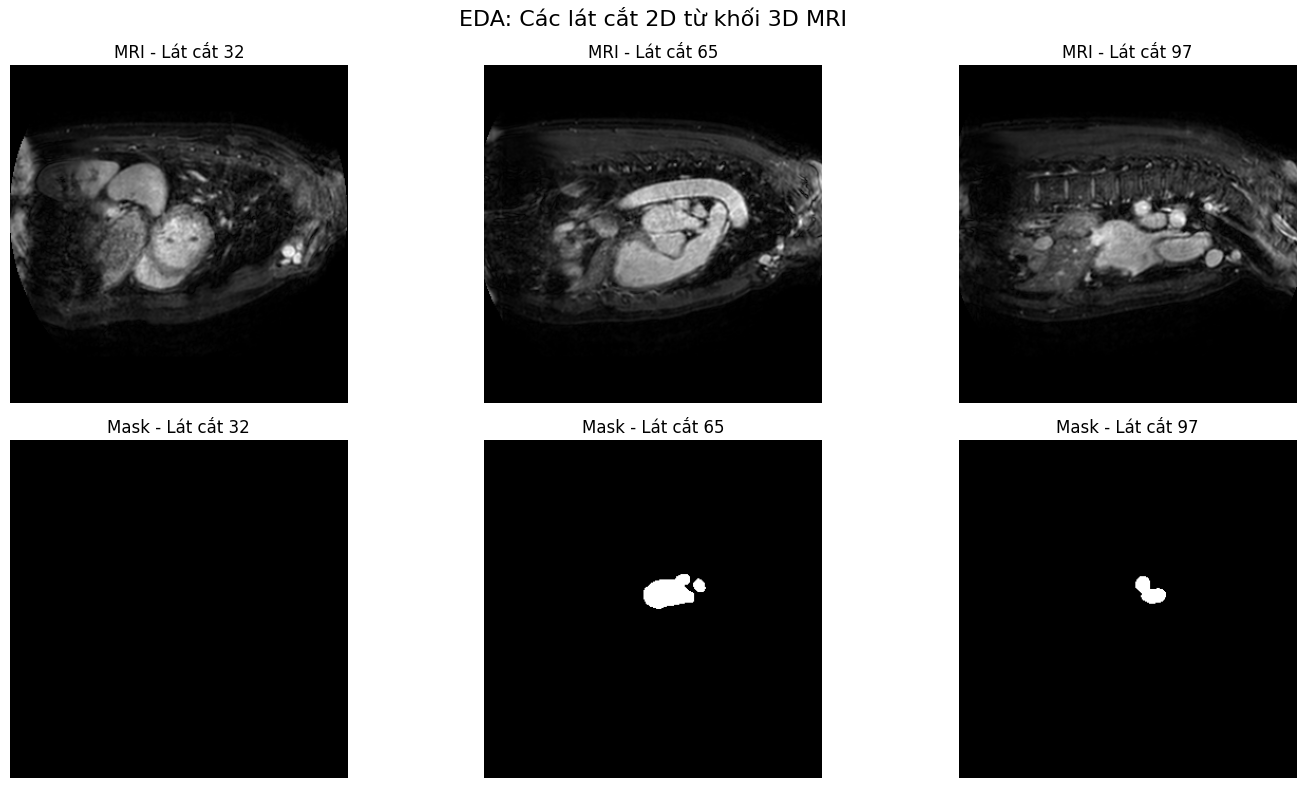

In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import os

# 1. Định nghĩa đường dẫn
# Nhớ thay đổi 'la_003.nii' thành một tên file thực tế có trong thư mục của bạn
image_filename = 'la_003.nii.gz' # hoặc .nii.gz
label_filename = 'la_003.nii.gz' # File label thường có tên giống hệt file image tương ứng

image_path = os.path.join('data', 'raw_3d', 'imagesTr', image_filename)
label_path = os.path.join('data', 'raw_3d', 'labelsTr', label_filename)

# 2. Đọc file .nii bằng nibabel
try:
    img_obj = nib.load(image_path)
    label_obj = nib.load(label_path)
    
    # Chuyển đổi thành dạng ma trận numpy
    img_data = img_obj.get_fdata()
    label_data = label_obj.get_fdata()

    # In ra kích thước của khối 3D (Thường là: Dài x Rộng x Số lát cắt)
    print("Kích thước khối MRI 3D:", img_data.shape)
    print("Kích thước khối Nhãn 3D:", label_data.shape)

    # 3. Trực quan hóa một vài lát cắt ở giữa khối 3D
    num_slices = img_data.shape[2] # Lấy số lượng lát cắt (chiều Z)
    
    # Chọn 3 lát cắt ở giữa để xem
    slices_to_show = [num_slices // 4, num_slices // 2, (num_slices * 3) // 4]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('EDA: Các lát cắt 2D từ khối 3D MRI', fontsize=16)

    for i, slice_idx in enumerate(slices_to_show):
        # Hàng trên: Ảnh MRI gốc
        axes[0, i].imshow(img_data[:, :, slice_idx], cmap='gray')
        axes[0, i].set_title(f'MRI - Lát cắt {slice_idx}')
        axes[0, i].axis('off')

        # Hàng dưới: Nhãn (Mask) của tâm nhĩ trái
        axes[1, i].imshow(label_data[:, :, slice_idx], cmap='gray')
        axes[1, i].set_title(f'Mask - Lát cắt {slice_idx}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Có lỗi xảy ra: {e}")
    print("Vui lòng kiểm tra lại đường dẫn hoặc tên file!")